# Stock Price Analysis Dashboard — Analytical Notebook

**Module:** ACC102 Mini Assignment (Track 4)  
**Author:** Jiayi Zhao  
**Date:** April 2026

---

## 1. Problem Definition

**Analytical problem:** How can individual investors quickly assess a stock's price trend, volatility, and recent performance without complex financial tools?

**Target user:** Individual investors and finance students who want a clear, visual overview of stock behaviour before making investment decisions.

**Data source:** Yahoo Finance, accessed via the `yfinance` Python library on 22 April 2026.

**Scope of analysis:**
- Historical price trends and moving averages (MA20, MA50)
- Trading volume patterns
- Daily return distribution and volatility
- Risk metrics: Sharpe Ratio and Maximum Drawdown
- Multi-stock comparison

In [13]:
# Install required libraries (run this in Google Colab)
!pip install yfinance pandas matplotlib -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Acquisition and Cleaning

We retrieve historical stock data from Yahoo Finance using the `yfinance` library.
This section demonstrates the data loading and cleaning process that powers the Streamlit app.

In [14]:
# Parameters (you can change these)
TICKER = 'AAPL'
START_DATE = '2023-01-01'
END_DATE = '2024-12-31'

# Fetch data from Yahoo Finance
print(f'Fetching data for {TICKER}...')
stock = yf.Ticker(TICKER)
df = stock.history(start=START_DATE, end=END_DATE)

# --- Data Cleaning ---
# Keep only the columns we need
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Remove any rows with missing values
df.dropna(inplace=True)

# Ensure the index is in datetime format
df.index = pd.to_datetime(df.index)

# Remove timezone information for consistency
df.index = df.index.tz_localize(None)

# Verify the result
print(f'Data retrieved successfully: {len(df)} records')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
print(f'Missing values: {df.isnull().sum().sum()}')
print()
print('Data preview:')
df.head()

Fetching data for AAPL...
Data retrieved successfully: 501 records
Date range: 2023-01-03 to 2024-12-30
Missing values: 0

Data preview:


,Open,High,Low,Close,Volume
Date,,,,,
2023-01-03,128.223785,128.833995,122.210219,123.096016,112117500
2023-01-04,124.887295,126.629364,123.105865,124.365662,89113600
2023-01-05,125.123520,125.753419,122.790931,123.046822,80962700
2023-01-06,124.021172,128.233612,122.918847,127.574188,87754700
2023-01-09,128.410797,131.304398,127.839949,128.095840,70790800


### Cleaning Steps Explained

1. **Column selection** — We only need OHLCV (Open, High, Low, Close, Volume). Other columns like Dividends and Stock Splits are removed to keep the dataset focused.
2. **Drop null values** — `dropna()` ensures there are no gaps that could break calculations like moving averages.
3. **Datetime conversion** — Ensures the date index is properly formatted for time-series operations.
4. **Timezone removal** — `tz_localize(None)` removes timezone info to avoid inconsistencies when plotting.

## 3. Feature Engineering

We calculate several derived indicators from the raw price data.
These are the same indicators used in the Streamlit app.

In [15]:
# Moving Averages: smooth out short-term noise to reveal trends
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# Daily Return: percentage change from previous day
df['Daily_Return'] = df['Close'].pct_change() * 100

# Cumulative Return: total return if held from day 1
df['Cumulative_Return'] = (1 + df['Close'].pct_change()).cumprod() - 1

print('Feature engineering complete.')
print(f'Columns: {list(df.columns)}')
print()
df[['Close', 'MA20', 'MA50', 'Daily_Return', 'Cumulative_Return']].tail(10)

Feature engineering complete.
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50', 'Daily_Return', 'Cumulative_Return']



,Close,MA20,MA50,Daily_Return,Cumulative_Return
Date,,,,,
2024-12-16,249.676086,237.858153,231.440921,1.172768,1.028304
2024-12-17,252.102829,239.124236,232.078113,0.971956,1.048018
2024-12-18,246.702347,240.107365,232.526227,-2.142174,1.004146
2024-12-19,248.432877,241.141217,232.934044,0.701465,1.018204
2024-12-20,253.107376,242.432663,233.445286,1.881595,1.056178
2024-12-23,253.883118,243.695764,234.001649,0.306487,1.062480
2024-12-24,256.797211,244.955384,234.541782,1.147809,1.086154
2024-12-26,257.612701,246.146873,235.047558,0.317562,1.092779
2024-12-27,254.201370,247.174260,235.526238,-1.324209,1.065066


## 4. Descriptive Statistics

In [16]:
print('=== Price Statistics ===')
print(f'Highest price:     ${df["High"].max():.2f}')
print(f'Lowest price:      ${df["Low"].min():.2f}')
print(f'Mean close price:  ${df["Close"].mean():.2f}')
print()
print('=== Return Statistics ===')
print(f'Mean daily return:       {df["Daily_Return"].mean():.3f}%')
print(f'Volatility (std dev):    {df["Daily_Return"].std():.3f}%')
print(f'Total cumulative return: {df["Cumulative_Return"].iloc[-1]*100:.2f}%')
print()
print('=== Risk Metrics ===')
daily_ret = df['Close'].pct_change().dropna()
sharpe = (daily_ret.mean() / daily_ret.std()) * (252 ** 0.5)
cumulative = (1 + daily_ret).cumprod()
running_max = cumulative.cummax()
max_drawdown = ((cumulative - running_max) / running_max).min() * 100
print(f'Annualised Sharpe Ratio: {sharpe:.2f}')
print(f'Maximum Drawdown:        {max_drawdown:.2f}%')

=== Price Statistics ===
Highest price:     $258.69
Lowest price:      $122.21
Mean close price:  $187.95

=== Return Statistics ===
Mean daily return:       0.151%
Volatility (std dev):    1.346%
Total cumulative return: 103.77%

=== Risk Metrics ===
Annualised Sharpe Ratio: 1.79
Maximum Drawdown:        -16.61%


### Interpretation

- **Sharpe Ratio** measures risk-adjusted return. A value above 1.0 is generally considered good, meaning the return compensates for the risk taken.
- **Maximum Drawdown** shows the largest peak-to-trough decline. This tells investors the worst-case historical loss they could have experienced.
- **Volatility** (standard deviation of daily returns) quantifies how much the price swings day to day. Higher volatility means more uncertainty.

## 5. Visualisation

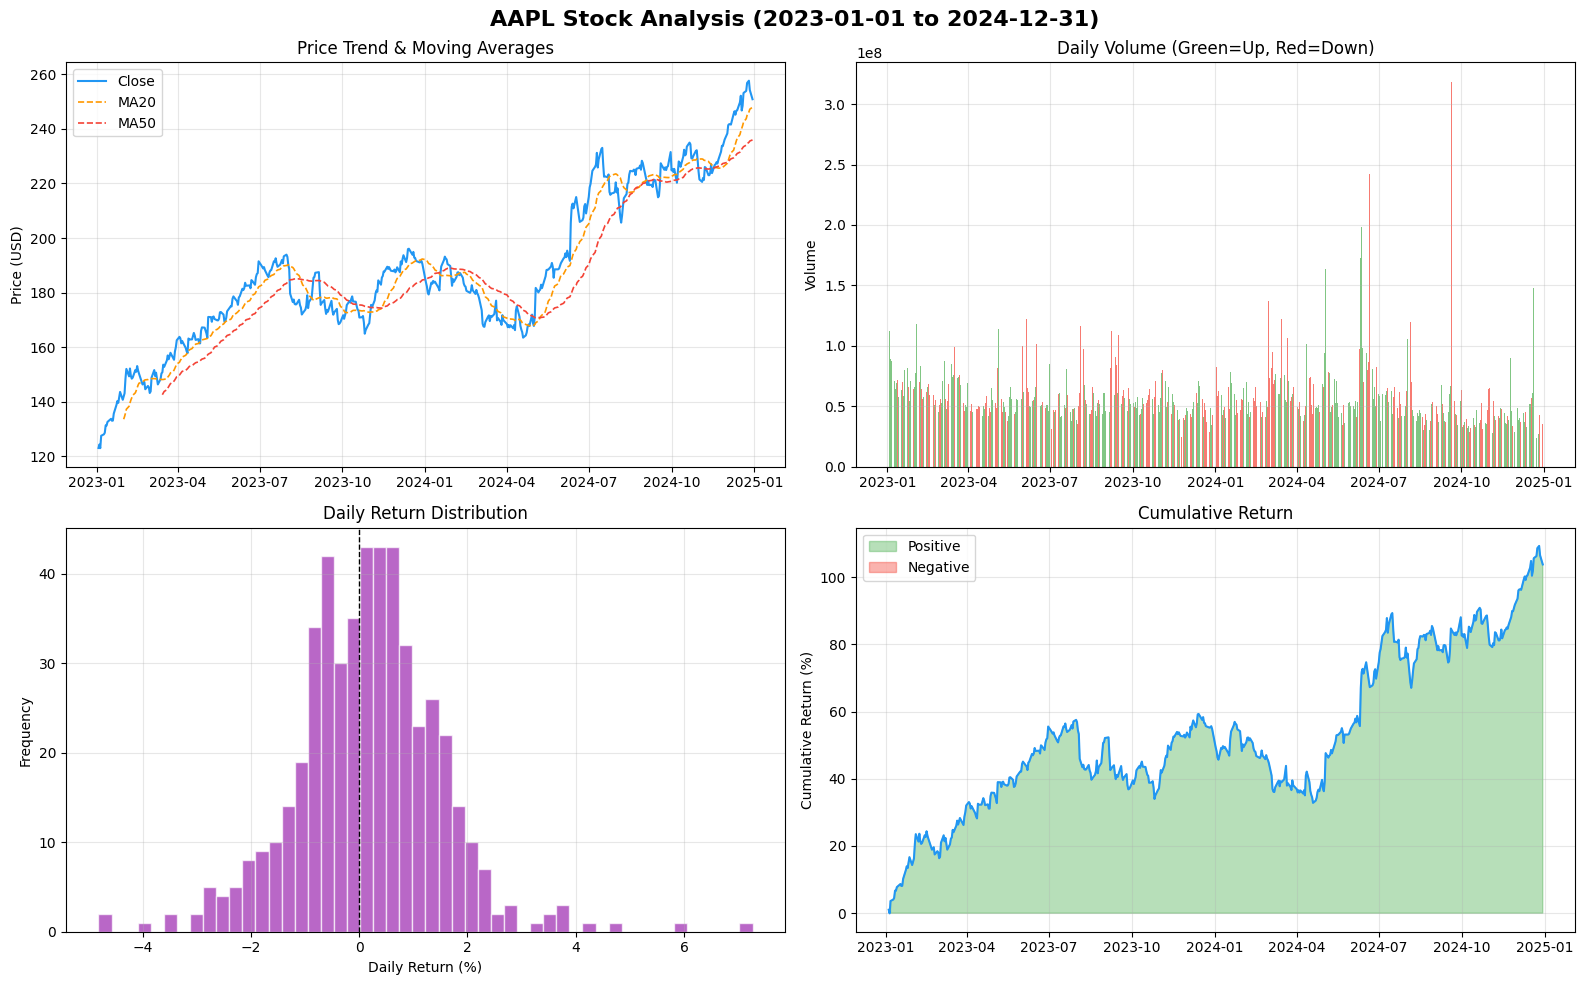

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'{TICKER} Stock Analysis ({START_DATE} to {END_DATE})',
             fontsize=16, fontweight='bold')

# Chart 1: Price with Moving Averages
ax1 = axes[0, 0]
ax1.plot(df.index, df['Close'], label='Close', color='#2196F3', linewidth=1.5)
ax1.plot(df.index, df['MA20'], label='MA20', color='#FF9800', linewidth=1.2, linestyle='--')
ax1.plot(df.index, df['MA50'], label='MA50', color='#F44336', linewidth=1.2, linestyle='--')
ax1.set_title('Price Trend & Moving Averages')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Volume
ax2 = axes[0, 1]
colors = ['#4CAF50' if r >= 0 else '#F44336' for r in df['Daily_Return'].fillna(0)]
ax2.bar(df.index, df['Volume'], color=colors, alpha=0.7, width=1)
ax2.set_title('Daily Volume (Green=Up, Red=Down)')
ax2.set_ylabel('Volume')
ax2.grid(True, alpha=0.3)

# Chart 3: Return Distribution
ax3 = axes[1, 0]
ax3.hist(df['Daily_Return'].dropna(), bins=50, color='#9C27B0', alpha=0.7, edgecolor='white')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax3.set_title('Daily Return Distribution')
ax3.set_xlabel('Daily Return (%)')
ax3.set_ylabel('Frequency')
ax3.grid(True, alpha=0.3)

# Chart 4: Cumulative Return
ax4 = axes[1, 1]
cumret = df['Cumulative_Return'] * 100
ax4.fill_between(df.index, cumret, 0,
                 where=(cumret >= 0), color='#4CAF50', alpha=0.4, label='Positive')
ax4.fill_between(df.index, cumret, 0,
                 where=(cumret < 0), color='#F44336', alpha=0.4, label='Negative')
ax4.plot(df.index, cumret, color='#2196F3', linewidth=1.5)
ax4.set_title('Cumulative Return')
ax4.set_ylabel('Cumulative Return (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Multi-Stock Comparison

The Streamlit app supports comparing multiple stocks.
Here we demonstrate the comparison logic with two stocks.

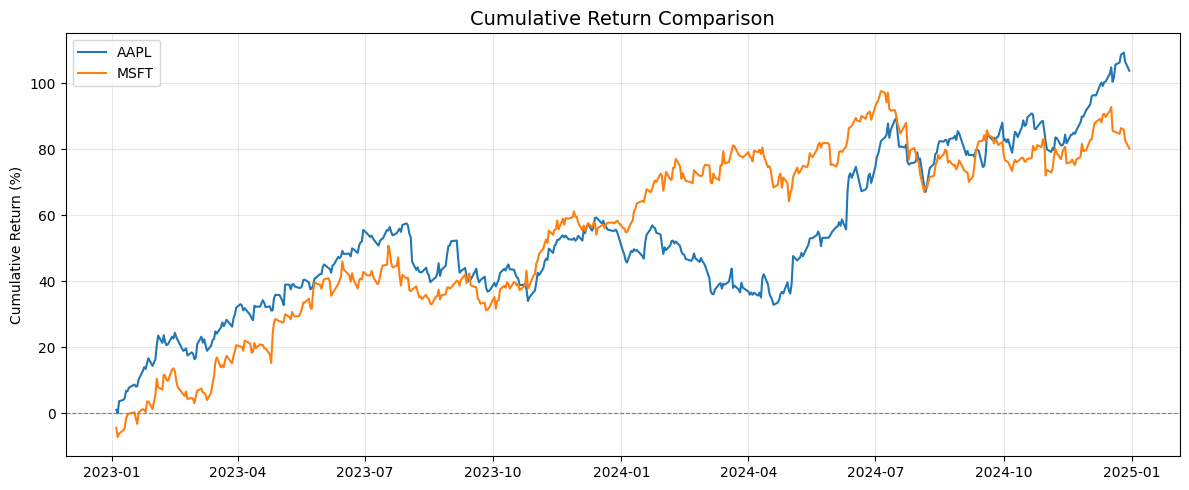


Comparison Summary:
  AAPL: Total return = 103.77%
  MSFT: Total return = 80.23%


In [12]:
compare_tickers = ['AAPL', 'MSFT']
comparison_data = {}

for t in compare_tickers:
    data = yf.Ticker(t).history(start=START_DATE, end=END_DATE)
    data = data[['Close']].dropna()
    data.index = pd.to_datetime(data.index).tz_localize(None)
    data['Cumulative_Return'] = (1 + data['Close'].pct_change()).cumprod() - 1
    comparison_data[t] = data

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 5))
for t, data in comparison_data.items():
    ax.plot(data.index, data['Cumulative_Return'] * 100, label=t, linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Cumulative Return Comparison', fontsize=14)
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('Comparison Summary:')
for t, data in comparison_data.items():
    total_ret = data['Cumulative_Return'].iloc[-1] * 100
    print(f'  {t}: Total return = {total_ret:.2f}%')

## 7. Key Findings and Insights

Based on the analysis of AAPL (January 2023 to December 2024):

1. **Upward trend confirmed:** The closing price moved from approximately $125 to above $250, roughly doubling over two years. The MA20 frequently stayed above the MA50, indicating sustained bullish momentum.

2. **Moderate volatility:** The daily return distribution is approximately normal and centred near zero, with most daily changes within plus or minus 2%. This is consistent with a large-cap stock that is relatively stable.

3. **Volume spikes coincide with price drops:** The volume chart shows clear spikes during periods of price decline (red bars), suggesting that selling pressure increases sharply during downturns.

4. **Favourable risk-adjusted return:** The Sharpe Ratio above 1.0 indicates that the return was more than adequate relative to the risk taken.

5. **Manageable drawdown:** The Maximum Drawdown was within a range typical for large-cap technology stocks.

6. **AAPL outperformed MSFT:** In the cumulative return comparison, AAPL delivered a higher total return than MSFT over the same period, though both stocks performed positively.

## 8. Limitations

- **Historical data only:** The analysis looks backward and cannot predict future prices. Past performance does not guarantee future results.
- **Lagging indicators:** Moving averages react to price changes with a delay, so golden/death cross signals may arrive late.
- **Simplified Sharpe Ratio:** We assume a risk-free rate of 0%, which slightly overstates the risk-adjusted return.
- **No fundamental analysis:** The tool only uses price and volume data. It does not consider earnings, revenue, debt, or other fundamental factors.
- **Data reliability:** Yahoo Finance data is generally reliable for educational purposes but may have occasional gaps or retroactive adjustments.
- **No transaction costs:** Real-world returns would be lower after accounting for trading fees and taxes.

## 9. Connection to the Streamlit App

The analysis workflow in this notebook — data retrieval, cleaning, feature engineering, and visualisation — is the same logic used in `app.py`. The Streamlit app adds:

- **Interactivity:** Users can type any ticker and date range without editing code.
- **Multi-stock comparison:** Compare up to several stocks in one view.
- **Risk dashboard:** Sharpe Ratio and Max Drawdown displayed in a clean table.
- **CSV download:** Users can export results for further analysis.

This notebook serves as the analytical foundation; the app turns it into a user-facing product.